# Phase 6 (Bonus) — ParsBERT Beyond the Bag-of-Words Ceiling

Phases 1–5 exhaust the **classical** pipeline: Count / TF-IDF / Word2Vec features fed to
classical models and a stacking ensemble. On Snappfood that tops out around an F1 of
**~0.845** — the *bag-of-words ceiling*. A bag of words throws away word **order** and
**context**, and that discarded information is exactly what separates the last few points of
accuracy from the rest.

**ParsBERT** (`HooshvareLab/bert-base-parsbert-uncased`) is a Persian BERT that reads a
sentence *in order, in context*. We use it in two escalating ways:

| Approach | What changes | Cost | Typical gain |
|---|---|---|---|
| **Frozen feature extraction** (this notebook, main path) | Run ParsBERT once as a fixed encoder, mean-pool to one 768-dim vector per review, feed those to the SAME classical heads / stacking | CPU-friendly, no training loop | several points over the BoW ceiling |
| **End-to-end fine-tuning** (optional section) | Unfreeze ParsBERT and train the whole network on the labels | needs a GPU + a training loop | squeezes out the last couple of points |

**Why frozen features still beat classical reps:** even without fine-tuning, each pooled
vector already encodes contextual meaning — negation, sarcasm cues, and word sense that
survive only when order is preserved. The classical heads then do the easy part: drawing a
boundary in that richer 768-dim space.

> This is the **bonus** phase. The required deliverable is complete after Phase 5. Nothing
> here is needed to satisfy the project spec — it is purely for maximum accuracy.

## 0. Dependencies (run once)

`torch` and `transformers` are **only** needed for this bonus notebook — the core project
does not import them. Run the cell below once; skip it if they are already installed. The
first call to ParsBERT downloads ~600 MB from the HuggingFace hub and caches it locally.

In [1]:
# Optional install. Comment out once the packages are present.
# A CUDA GPU is auto-detected if available; CPU also works (slower).
# %pip install -q transformers

In [2]:
import sys, os, json, time, warnings
warnings.filterwarnings('ignore')

REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
for p in [REPO_ROOT, os.path.join(REPO_ROOT, 'src')]:
    if p not in sys.path:
        sys.path.insert(0, p)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline      import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm           import LinearSVC
from sklearn.calibration   import CalibratedClassifierCV
from sklearn.linear_model  import LogisticRegression
from sklearn.ensemble      import (StackingClassifier, RandomForestClassifier,
                                   HistGradientBoostingClassifier)

from bert_features import ParsBertFeatureExtractor
from evaluation    import (evaluate_model, plot_confusion_matrix,
                           full_report, print_metrics_table, save_results_csv)

DATA_PROC = os.path.join(REPO_ROOT, 'data', 'processed')
RES_DIR   = os.path.join(REPO_ROOT, 'outputs', 'results')
CM_DIR    = os.path.join(REPO_ROOT, 'outputs', 'confusion_matrices')
FIG_DIR   = os.path.join(REPO_ROOT, 'outputs', 'figures')
for d in (RES_DIR, CM_DIR, FIG_DIR):
    os.makedirs(d, exist_ok=True)

print('Imports OK')

Imports OK


## 1. Load RAW Text + Labels

Feed ParsBERT the **original Persian comment**, NOT the cleaned/negation-tagged tokens.
ParsBERT has its own WordPiece tokenizer and was pretrained on natural text — our `EMO_` /
`NEG_` markers and aggressive cleaning would only confuse it. The labels are the same
`y_train` / `y_test` arrays every other phase uses, so results are directly comparable.

In [3]:
train_df = pd.read_csv(os.path.join(DATA_PROC, 'train.csv'), encoding='utf-8')
test_df  = pd.read_csv(os.path.join(DATA_PROC, 'test.csv'),  encoding='utf-8')

# Raw text column preserved by Phase 1 specifically for the transformer path.
train_texts = train_df['comment'].fillna('').astype(str).tolist()
test_texts  = test_df['comment'].fillna('').astype(str).tolist()

# Prefer the cached label arrays every other phase uses; fall back to the CSV's
# own 'label' column if they are missing (e.g. this notebook run standalone,
# before 01_preprocessing.ipynb has produced y_train.npy / y_test.npy).
y_train_path = os.path.join(DATA_PROC, 'y_train.npy')
y_test_path  = os.path.join(DATA_PROC, 'y_test.npy')

if os.path.exists(y_train_path) and os.path.exists(y_test_path):
    y_train = np.load(y_train_path)
    y_test  = np.load(y_test_path)
else:
    print('[bert05load] y_train.npy / y_test.npy not found — falling back to the '
          "CSV 'label' column.")
    y_train = train_df['label'].to_numpy()
    y_test  = test_df['label'].to_numpy()

print(f'Train reviews: {len(train_texts):,}   Test reviews: {len(test_texts):,}')
print(f'Example raw comment: {train_texts[0][:120]}')

Train reviews: 55,583   Test reviews: 13,896
Example raw comment: سلام دستم اشتباهی خورد روی ناراضی در صورتیکه از همه چیز راضی بودم


## 2. Extract Frozen ParsBERT Features (cached to disk)

Encoding 70k reviews is the slow step (minutes on GPU, longer on CPU). We cache the
resulting matrices to `data/processed/X_*_bert.npy` and reload them on subsequent runs so the
encoder only runs once. Delete those files to force a re-encode.

In [4]:
X_train_bert_path = os.path.join(DATA_PROC, 'X_train_bert.npy')
X_test_bert_path  = os.path.join(DATA_PROC, 'X_test_bert.npy')

if os.path.exists(X_train_bert_path) and os.path.exists(X_test_bert_path):
    X_train_bert = np.load(X_train_bert_path)
    X_test_bert  = np.load(X_test_bert_path)
    print('Loaded cached ParsBERT features.')
else:
    enc = ParsBertFeatureExtractor(max_length=128, batch_size=32, pooling='mean')
    print(f'Encoding with frozen ParsBERT on device: {enc._device or "auto"} ...')

    t0 = time.time()
    X_train_bert = enc.transform(train_texts)
    X_test_bert  = enc.transform(test_texts)
    print(f'Encoding done in {time.time() - t0:.1f}s')

    np.save(X_train_bert_path, X_train_bert)
    np.save(X_test_bert_path,  X_test_bert)
    print('Cached features to data/processed/.')

print(f'Feature shapes: train {X_train_bert.shape}, test {X_test_bert.shape}')

Loaded cached ParsBERT features.
Feature shapes: train (55583, 768), test (13896, 768)


## 3. Classical Heads on ParsBERT Features

The 768-dim pooled vectors are **dense** and contain negative values, so we use the
dense-friendly linear models. We standardize first (`StandardScaler`) because SVM and
LogisticRegression are scale-sensitive and BERT dimensions have very different variances.
These are the same model families used in the classical phases — only the input
representation changed, which is what isolates the contribution of contextual features.

In [5]:
REP = 'ParsBERT-frozen'
bert_results = []

heads = {
    'SVM (Linear)': make_pipeline(
        StandardScaler(),
        CalibratedClassifierCV(LinearSVC(C=1.0, max_iter=5000)),
    ),
    'LogisticRegression': make_pipeline(
        StandardScaler(),
        LogisticRegression(C=1.0, max_iter=2000, solver='lbfgs', n_jobs=-1),
    ),
    'HistGradientBoosting': HistGradientBoostingClassifier(
        max_iter=400, learning_rate=0.08, random_state=42,
    ),
}

for name, clf in heads.items():
    t0 = time.time()
    clf.fit(X_train_bert, y_train)
    y_pred = clf.predict(X_test_bert)
    metrics = evaluate_model(name, REP, y_test, y_pred)
    metrics['train_time_s'] = round(time.time() - t0, 1)
    bert_results.append(metrics)
    print(f"{name:<22} F1={metrics['f1']:.4f}  acc={metrics['accuracy']:.4f}  "
          f"({metrics['train_time_s']}s)")

print()
print_metrics_table(bert_results)

SVM (Linear)           F1=0.8445  acc=0.8447  (51.6s)
LogisticRegression     F1=0.8438  acc=0.8440  (3.9s)
HistGradientBoosting   F1=0.8357  acc=0.8361  (13.2s)

               model      vectorizer accuracy precision recall     f1
        SVM (Linear) ParsBERT-frozen   84.47%    84.69% 84.47% 84.45%
  LogisticRegression ParsBERT-frozen   84.40%    84.61% 84.40% 84.38%
HistGradientBoosting ParsBERT-frozen   83.61%    83.94% 83.61% 83.57%


## 4. Stacking on ParsBERT Features

Same decorrelated-stacking idea as Phase 5, adapted to the dense BERT space: a max-margin
model, a probabilistic-linear model, gradient boosting, and bagged trees, combined by a
LogisticRegression meta-learner over their out-of-fold probabilities.

**A caveat worth flagging:** every base member in this stack is trained on the *same*
768-dim frozen-ParsBERT representation. Stacking decorrelates model *families* (margin-based,
probabilistic, boosted, bagged), but they all see the same input space, so their errors are
still more correlated than an ensemble that mixes *representations* too. Section 6.5 below
builds a second ensemble that mixes representations (Hybrid TF-IDF, plain TF-IDF, frozen
ParsBERT, and fine-tuned ParsBERT) precisely to push past that ceiling.

Stacking on ParsBERT  F1=0.8451  acc=0.8453  (1545.3s)

Model: Stacking   |   Vectorizer: ParsBERT-frozen
              precision    recall  f1-score   support

         Sad       0.82      0.88      0.85      6913
       Happy       0.87      0.81      0.84      6983

    accuracy                           0.85     13896
   macro avg       0.85      0.85      0.85     13896
weighted avg       0.85      0.85      0.85     13896



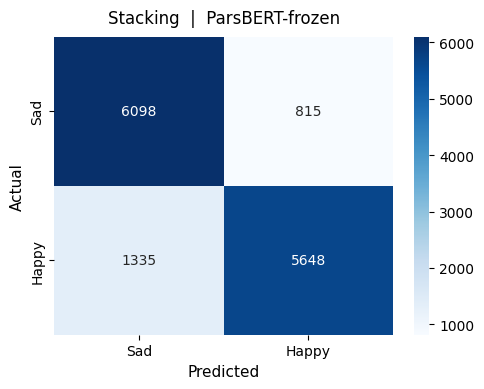

In [6]:
bert_base = [
    ('svm', make_pipeline(StandardScaler(),
                          CalibratedClassifierCV(LinearSVC(C=1.0, max_iter=5000)))),
    ('lr',  make_pipeline(StandardScaler(),
                          LogisticRegression(C=1.0, max_iter=2000, n_jobs=1))),
    ('hgb', HistGradientBoostingClassifier(max_iter=400, learning_rate=0.08, random_state=42)),
    ('rf',  RandomForestClassifier(n_estimators=300, n_jobs=1, random_state=42)),
]

bert_stack = StackingClassifier(
    estimators=bert_base,
    final_estimator=LogisticRegression(C=1.0, max_iter=1000),
    cv=5, stack_method='auto', n_jobs=2, passthrough=False,
)

t0 = time.time()
bert_stack.fit(X_train_bert, y_train)
y_pred_stack = bert_stack.predict(X_test_bert)
stack_metrics = evaluate_model('Stacking', REP, y_test, y_pred_stack)
stack_metrics['train_time_s'] = round(time.time() - t0, 1)
bert_results.append(stack_metrics)

print(f"Stacking on ParsBERT  F1={stack_metrics['f1']:.4f}  "
      f"acc={stack_metrics['accuracy']:.4f}  ({stack_metrics['train_time_s']}s)")
full_report('Stacking', REP, y_test, y_pred_stack)
plot_confusion_matrix('Stacking', REP, y_test, y_pred_stack, CM_DIR, show=True)

## 5. ParsBERT vs. the Classical Ceiling

Pull the best classical numbers from Phase 3 (single models) and Phase 5 (stacking) and put
the ParsBERT results next to them. The gap is the payoff for modelling word order and
context instead of throwing them away.

In [7]:
rows = []

# Classical single-model ceiling from Phase 3.
p3_path = os.path.join(RES_DIR, 'phase3_results.csv')
if os.path.exists(p3_path):
    p3 = pd.read_csv(p3_path)
    best3 = p3.loc[p3['f1'].idxmax()]
    rows.append({'Stage': 'Classical best single',
                 'Model': f"{best3['model']} / {best3['vectorizer']}",
                 'Accuracy': round(float(best3['accuracy']), 4),
                 'F1': round(float(best3['f1']), 4)})

# Classical stacking from Phase 5.
p5_path = os.path.join(RES_DIR, 'phase5_stacking_results.json')
if os.path.exists(p5_path):
    with open(p5_path, encoding='utf-8') as f:
        p5 = json.load(f)
    rows.append({'Stage': 'Classical stacking',
                 'Model': f"Stacking / {p5['vectorizer_used']}",
                 'Accuracy': p5['stacking_accuracy'], 'F1': p5['stacking_f1']})

# ParsBERT results from this notebook.
best_bert = max(bert_results, key=lambda r: r['f1'])
for r in bert_results:
    rows.append({'Stage': f"ParsBERT — {r['model']}",
                 'Model': f"{r['model']} / {REP}",
                 'Accuracy': r['accuracy'], 'F1': r['f1']})

cmp_df = pd.DataFrame(rows).sort_values('F1').reset_index(drop=True)
print(cmp_df.to_string(index=False))
print()
if rows and len(rows) >= 2:
    classical_best = max((r['F1'] for r in rows if 'ParsBERT' not in r['Stage']), default=0.0)
    print(f"Best classical F1 : {classical_best:.4f}")
    print(f"Best ParsBERT F1  : {best_bert['f1']:.4f}")
    print(f"Gain from context : {best_bert['f1'] - classical_best:+.4f}")

                          Stage                                  Model  Accuracy     F1
ParsBERT — HistGradientBoosting HistGradientBoosting / ParsBERT-frozen    0.8361 0.8357
  ParsBERT — LogisticRegression   LogisticRegression / ParsBERT-frozen    0.8440 0.8438
        ParsBERT — SVM (Linear)         SVM (Linear) / ParsBERT-frozen    0.8447 0.8445
            ParsBERT — Stacking             Stacking / ParsBERT-frozen    0.8453 0.8451
          Classical best single          SVM (Linear) (tuned) / Hybrid    0.8578 0.8574
             Classical stacking                      Stacking / Hybrid    0.8580 0.8578

Best classical F1 : 0.8578
Best ParsBERT F1  : 0.8451
Gain from context : -0.0127


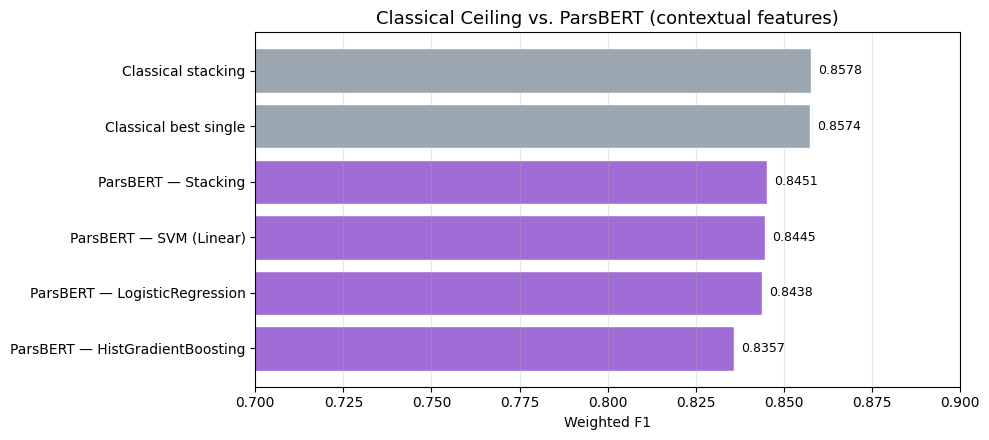

In [8]:
fig, ax = plt.subplots(figsize=(10, 4.5))
order = cmp_df.sort_values('F1', ascending=True)
colors = ['#9aa7b1' if 'ParsBERT' not in s else '#A06CD5' for s in order['Stage']]
ax.barh(order['Stage'], order['F1'], color=colors, edgecolor='white')
for y, v in enumerate(order['F1']):
    ax.text(v + 0.002, y, f'{v:.4f}', va='center', fontsize=9)
ax.set_xlim(0.7, max(0.9, order['F1'].max() + 0.03))
ax.set_xlabel('Weighted F1')
ax.set_title('Classical Ceiling vs. ParsBERT (contextual features)', fontsize=13)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'parsbert_vs_classical.png'), dpi=120, bbox_inches='tight')
plt.show()

In [9]:
save_results_csv(bert_results, os.path.join(RES_DIR, 'phase6_bert_results.csv'))

summary = {
    'representation':   REP,
    'best_bert_model':  best_bert['model'],
    'best_bert_f1':     best_bert['f1'],
    'best_bert_accuracy': best_bert['accuracy'],
    'all_results':      bert_results,
}
with open(os.path.join(RES_DIR, 'phase6_bert_summary.json'), 'w', encoding='utf-8') as f:
    json.dump(summary, f, indent=2, ensure_ascii=False)
print('Saved: outputs/results/phase6_bert_results.csv')
print('Saved: outputs/results/phase6_bert_summary.json')

[evaluation] Results saved to /mnt/e/University/University_Subjects/6th/Computational_Intelligence/Projects/3/NLP-Ensemble/outputs/results/phase6_bert_results.csv
Saved: outputs/results/phase6_bert_results.csv
Saved: outputs/results/phase6_bert_summary.json


## 6. (Optional) End-to-End Fine-Tuning

Frozen features already break the BoW ceiling. The last couple of points come from
**fine-tuning**: unfreezing ParsBERT and training the whole network on the sentiment labels
so the encoder reshapes its representation around *this* task (and the `[CLS]` token finally
becomes a good sentence summary).

This needs a **GPU** and a real training loop, so it is gated behind `RUN_FINETUNE = False`.
Flip it to `True` on a CUDA machine to run. Expect 2–3 epochs to be enough; more tends to
overfit 70k short reviews.

**Blend-holdout split (feeds Section 6.5 too).** Rather than fine-tuning on the full training
set, we carve off a stratified 10% **blend** set from `train` (seed 42). ParsBERT is
fine-tuned on the remaining 90% (**train_base**) only, using **blend** as the eval set for
`load_best_model_at_end`. This does two things at once:

1. Gives a clean fine-tuned-ParsBERT number on `test` (the model never saw `test` during
   training or model selection — no leakage).
2. Produces softmax probabilities on `blend` and `test` from a *single fine-tune run*, which
   Section 6.5 reuses as one member of a mixed-representation ensemble, with `blend`
   fitting the meta-learner and `test` evaluated once. Re-fine-tuning per experiment would be
   far too slow, so this one run is deliberately shared between Section 6 and Section 6.5.

**What the cell does:** splits `train` into `train_base` / `blend`, tokenizes the raw text,
wraps it in a `Dataset`, loads `AutoModelForSequenceClassification` (a classification head on
top of ParsBERT), and trains with HuggingFace `Trainer` using a small learning rate (`2e-5`)
typical for BERT fine-tuning. `TrainingArguments` are set for reproducibility and to always
keep the best checkpoint: `num_train_epochs=3`, `warmup_ratio=0.1`, `fp16=True` (mixed
precision — needs a CUDA GPU), `save_strategy='epoch'`, `load_best_model_at_end=True`,
`metric_for_best_model='accuracy'`, `seed=42`.

In [10]:
from transformers.utils.import_utils import is_accelerate_available
is_accelerate_available.cache_clear()

import accelerate
print("accelerate version now visible:", accelerate.__version__)
print("is_accelerate_available():", is_accelerate_available())

accelerate version now visible: 1.14.0
is_accelerate_available(): True


In [ ]:
RUN_FINETUNE = True  # set True on a GPU machine to fine-tune end-to-end

# Indices for the blend-holdout split are computed unconditionally (cheap, CPU-only)
# so Section 6.5 can reference them (and the label splits) even when
# RUN_FINETUNE is False.
from sklearn.model_selection import train_test_split

idx_all = np.arange(len(y_train))
idx_base, idx_blend = train_test_split(
    idx_all, test_size=0.10, stratify=y_train, random_state=42,
)
y_train_base = y_train[idx_base]
y_blend      = y_train[idx_blend]
print(f'train_base: {len(idx_base):,} rows   blend: {len(idx_blend):,} rows')

if RUN_FINETUNE:
    import torch
    from torch.utils.data import Dataset
    from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                              TrainingArguments, Trainer)
    from sklearn.metrics import accuracy_score, f1_score

    MODEL_NAME = 'HooshvareLab/bert-base-parsbert-uncased'
    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

    train_base_texts = [train_texts[i] for i in idx_base]
    blend_texts       = [train_texts[i] for i in idx_blend]

    class ReviewDataset(Dataset):
        def __init__(self, texts, labels, tok, max_length=128):
            self.enc = tok(list(texts), truncation=True, padding=True,
                           max_length=max_length)
            self.labels = list(labels)
        def __len__(self):
            return len(self.labels)
        def __getitem__(self, i):
            item = {k: torch.tensor(v[i]) for k, v in self.enc.items()}
            item['labels'] = torch.tensor(int(self.labels[i]))
            return item

    train_base_ds = ReviewDataset(train_base_texts, y_train_base, tokenizer)
    blend_ds      = ReviewDataset(blend_texts,       y_blend,      tokenizer)
    test_ds       = ReviewDataset(test_texts,        y_test,       tokenizer)

    model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)

    def compute_metrics(eval_pred):
        logits, labels = eval_pred
        preds = logits.argmax(axis=-1)
        return {'accuracy': accuracy_score(labels, preds),
                'f1': f1_score(labels, preds, average='weighted')}

    args = TrainingArguments(
        output_dir=os.path.join(REPO_ROOT, 'outputs', 'parsbert_finetune'),
        num_train_epochs=3,
        per_device_train_batch_size=32,
        per_device_eval_batch_size=64,
        learning_rate=2e-5,
        weight_decay=0.01,
        warmup_ratio=0.1,
        fp16=True,
        eval_strategy='epoch',
        save_strategy='epoch',
        load_best_model_at_end=True,
        metric_for_best_model='accuracy',
        logging_steps=200,
        report_to='none',
        seed=42,
    )

    # Fine-tune on train_base only; blend is the eval set used for best-checkpoint
    # selection. test is held out entirely from training and model selection.
    trainer = Trainer(model=model, args=args, train_dataset=train_base_ds,
                      eval_dataset=blend_ds, compute_metrics=compute_metrics)
    trainer.train()

    # Softmax probabilities on blend (fits Section 6.5's meta-learner) and on
    # test (final, single evaluation — reused by both Section 6 and Section 6.5).
    blend_logits = trainer.predict(blend_ds).predictions
    test_logits  = trainer.predict(test_ds).predictions

    P_blend_bert_ft = torch.softmax(torch.tensor(blend_logits), dim=1).numpy()
    P_test_bert_ft  = torch.softmax(torch.tensor(test_logits),  dim=1).numpy()

    y_pred_ft = P_test_bert_ft.argmax(axis=1)
    ft_metrics = evaluate_model('ParsBERT (fine-tuned)', 'raw text', y_test, y_pred_ft)
    print(f"Fine-tuned ParsBERT   F1={ft_metrics['f1']:.4f}  acc={ft_metrics['accuracy']:.4f}")
    plot_confusion_matrix('ParsBERT (fine-tuned)', 'raw text', y_test, y_pred_ft, CM_DIR, show=True)

    np.save(os.path.join(DATA_PROC, 'P_blend_bert_ft.npy'), P_blend_bert_ft)
    np.save(os.path.join(DATA_PROC, 'P_test_bert_ft.npy'),  P_test_bert_ft)

    with open(os.path.join(RES_DIR, 'phase6_finetune_results.json'), 'w', encoding='utf-8') as f:
        json.dump({k: float(v) for k, v in ft_metrics.items() if isinstance(v, (int, float))},
                  f, indent=2)
    print('Saved: outputs/results/phase6_finetune_results.json')
    print('Saved: data/processed/P_blend_bert_ft.npy, P_test_bert_ft.npy (for Section 6.5)')
else:
    print('RUN_FINETUNE is False — skipping end-to-end fine-tuning.')
    print('Set RUN_FINETUNE = True on a GPU machine to run this section.')
    print('Section 6.5 (extended ensemble) needs these fine-tuned probabilities and will '
          'skip its fine-tuned-ParsBERT member if they are unavailable.')

train_base: 50,024 rows   blend: 5,559 rows


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: HooshvareLab/bert-base-parsbert-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING

Epoch,Training Loss,Validation Loss


## 6.5 Extended Ensemble — Mixing Representations, Not Just Model Families

Sections 4 and 5 (Phase 5) each stack multiple *models* over a *single* representation
(Hybrid TF-IDF, or frozen ParsBERT). That decorrelates model families but not the
information source — every member ultimately sees the same features, so their mistakes are
correlated on the same blind spots.

This section builds one more ensemble that mixes **representations** as well as models,
using a leak-free **blend-holdout** scheme instead of k-fold stacking (fine-tuning ParsBERT
5 times for a 5-fold stack would be far too slow):

- **train_base** (90% of train) fits every base member.
- **blend** (the held-out 10%, stratified, seed 42 — computed in Section 6 above) fits the
  meta-learner on the base members' predicted probabilities.
- **test** is scored exactly once, by the fitted meta-learner.

**The five members** (five different representations / algorithms):

| # | Representation | Model |
|---|---|---|
| 1 | Raw text, fine-tuned | ParsBERT (fine-tuned end-to-end, Section 6) |
| 2 | Hybrid word+char TF-IDF (upgraded sizing, fit on train_base) | `CalibratedClassifierCV(LinearSVC)` |
| 3 | Hybrid word+char TF-IDF (same matrix as #2) | `LogisticRegression` |
| 4 | Frozen ParsBERT (768-dim, mean-pooled) | `HistGradientBoostingClassifier` |
| 5 | Plain word TF-IDF (fit on train_base) | `ComplementNB` |

If the fine-tuned-ParsBERT probabilities from Section 6 are unavailable (i.e.
`RUN_FINETUNE` was `False`), member #1 is skipped automatically and the ensemble runs with
the remaining 4 members — the code degrades gracefully instead of failing.

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import ComplementNB
from sklearn.model_selection import GridSearchCV
from vectorizers import build_word_char_union

# ---- 1. Cleaned text for train_base / blend / test, split by the SAME indices ----
train_cleaned = train_df['cleaned'].fillna('').astype(str).to_numpy()
test_cleaned  = test_df['cleaned'].fillna('').astype(str).to_numpy()

cleaned_base  = train_cleaned[idx_base]
cleaned_blend = train_cleaned[idx_blend]

# ---- 2. Hybrid word+char TF-IDF, fit on train_base ONLY (same sizing as NB02) ----
hybrid_vec = build_word_char_union(
    word_ngram_range=(1, 2), char_ngram_range=(2, 5),
    word_max_features=100_000, char_max_features=300_000,
    min_df=3, sublinear_tf=True,
)
X_base_hybrid  = hybrid_vec.fit_transform(cleaned_base)
X_blend_hybrid = hybrid_vec.transform(cleaned_blend)
X_test_hybrid  = hybrid_vec.transform(test_cleaned)
print(f'Hybrid (train_base fit): {X_base_hybrid.shape}')

# ---- 3. Plain word TF-IDF, fit on train_base ONLY ----
word_vec = TfidfVectorizer(analyzer='word', ngram_range=(1, 2),
                           max_features=100_000, min_df=3, sublinear_tf=True)
X_base_word  = word_vec.fit_transform(cleaned_base)
X_blend_word = word_vec.transform(cleaned_blend)
X_test_word  = word_vec.transform(test_cleaned)
print(f'Plain word TF-IDF (train_base fit): {X_base_word.shape}')

# ---- 4. Frozen ParsBERT features, sliced by the SAME train indices ----
X_base_bert  = X_train_bert[idx_base]
X_blend_bert = X_train_bert[idx_blend]
# X_test_bert already loaded in Section 2.

# ---- 5. Fit the four always-available base members on train_base ----
ext_members = {}

svm_hybrid = make_pipeline(CalibratedClassifierCV(LinearSVC(C=0.5, max_iter=5000)))
svm_hybrid.fit(X_base_hybrid, y_train_base)
ext_members['SVM / Hybrid'] = (
    svm_hybrid.predict_proba(X_blend_hybrid), svm_hybrid.predict_proba(X_test_hybrid))

lr_hybrid = LogisticRegression(C=0.5, max_iter=3000, n_jobs=-1)
lr_hybrid.fit(X_base_hybrid, y_train_base)
ext_members['LogReg / Hybrid'] = (
    lr_hybrid.predict_proba(X_blend_hybrid), lr_hybrid.predict_proba(X_test_hybrid))

hgb_bert = HistGradientBoostingClassifier(max_iter=400, learning_rate=0.08, random_state=42)
hgb_bert.fit(X_base_bert, y_train_base)
ext_members['HGB / ParsBERT-frozen'] = (
    hgb_bert.predict_proba(X_blend_bert), hgb_bert.predict_proba(X_test_bert))

nb_word = ComplementNB(alpha=0.25)
nb_word.fit(X_base_word, y_train_base)
ext_members['ComplementNB / word TF-IDF'] = (
    nb_word.predict_proba(X_blend_word), nb_word.predict_proba(X_test_word))

# ---- 6. Add the fine-tuned ParsBERT member if Section 6 produced it ----
p_blend_ft_path = os.path.join(DATA_PROC, 'P_blend_bert_ft.npy')
p_test_ft_path  = os.path.join(DATA_PROC, 'P_test_bert_ft.npy')

if 'P_blend_bert_ft' in dir() and 'P_test_bert_ft' in dir():
    ext_members['ParsBERT (fine-tuned)'] = (P_blend_bert_ft, P_test_bert_ft)
elif os.path.exists(p_blend_ft_path) and os.path.exists(p_test_ft_path):
    ext_members['ParsBERT (fine-tuned)'] = (
        np.load(p_blend_ft_path), np.load(p_test_ft_path))
else:
    print('[Section 6.5] Fine-tuned ParsBERT probabilities not found — running the '
          'ensemble with the remaining 4 members. Set RUN_FINETUNE = True in Section 6 '
          'to add this member.')

print(f"\nExtended ensemble members: {list(ext_members.keys())}")

# ---- 7. Build meta-feature matrices (concat each member's proba on blend / test) ----
meta_X_blend = np.hstack([p_blend for p_blend, _ in ext_members.values()])
meta_X_test  = np.hstack([p_test  for _, p_test  in ext_members.values()])
print(f'Meta-feature shapes: blend {meta_X_blend.shape}, test {meta_X_test.shape}')

# ---- 8. Fit the meta-learner on blend, tuning C by CV on blend only ----
meta_search = GridSearchCV(
    LogisticRegression(max_iter=2000),
    param_grid={'C': [0.1, 0.3, 1.0]},
    cv=5, scoring='f1_weighted', n_jobs=-1,
)
meta_search.fit(meta_X_blend, y_blend)
meta_clf = meta_search.best_estimator_
print(f'Best meta-learner C: {meta_search.best_params_["C"]}  '
      f'(CV f1_weighted on blend = {meta_search.best_score_:.4f})')

# ---- 9. Evaluate ONCE on test ----
y_pred_ext = meta_clf.predict(meta_X_test)
ext_metrics = evaluate_model('Extended ensemble (meta)', 'mixed representations',
                             y_test, y_pred_ext)
print(f"\nExtended ensemble  F1={ext_metrics['f1']:.4f}  acc={ext_metrics['accuracy']:.4f}")
full_report('Extended ensemble (meta)', 'mixed representations', y_test, y_pred_ext)
plot_confusion_matrix('Extended ensemble (meta)', 'mixed representations',
                      y_test, y_pred_ext, CM_DIR, show=True)

print('\nMeta-learner coefficients (one row per class, one column per member proba column):')
print(meta_clf.coef_)

In [ ]:
# ---- Ladder comparison: classical stack -> frozen-BERT best -> fine-tuned ParsBERT
#      -> extended ensemble. Reuses the same rows built in Section 5's cmp_df where
#      possible, and adds the two new stages this section introduces.
ladder_rows = list(rows)  # from Section 5: classical best single/stacking + frozen-BERT heads

if 'ParsBERT (fine-tuned)' in ext_members:
    if os.path.exists(os.path.join(RES_DIR, 'phase6_finetune_results.json')):
        with open(os.path.join(RES_DIR, 'phase6_finetune_results.json'), encoding='utf-8') as f:
            ft_saved = json.load(f)
        ladder_rows.append({'Stage': 'ParsBERT — fine-tuned',
                            'Model': 'ParsBERT (fine-tuned) / raw text',
                            'Accuracy': round(ft_saved.get('accuracy', float('nan')), 4),
                            'F1': round(ft_saved.get('f1', float('nan')), 4)})

ladder_rows.append({'Stage': 'Extended ensemble (mixed reps)',
                    'Model': 'Meta-LogReg over 5 members',
                    'Accuracy': ext_metrics['accuracy'], 'F1': ext_metrics['f1']})

ladder_df = pd.DataFrame(ladder_rows).sort_values('F1').reset_index(drop=True)
print(ladder_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#A06CD5' if 'Extended' in s else ('#5DBB8A' if 'fine-tuned' in s else '#9aa7b1')
         for s in ladder_df['Stage']]
ax.barh(ladder_df['Stage'], ladder_df['F1'], color=colors, edgecolor='white')
for y, v in enumerate(ladder_df['F1']):
    ax.text(v + 0.002, y, f'{v:.4f}', va='center', fontsize=9)
ax.set_xlim(0.7, max(0.9, ladder_df['F1'].max() + 0.03))
ax.set_xlabel('Weighted F1')
ax.set_title('Full Ladder: Classical -> Frozen ParsBERT -> Fine-tuned -> Extended Ensemble',
             fontsize=13)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'phase6_full_ladder.png'), dpi=120, bbox_inches='tight')
plt.show()

# ---- Save ----
ext_summary = {
    'members':            list(ext_members.keys()),
    'meta_best_C':         meta_search.best_params_['C'],
    'meta_cv_f1_blend':    round(meta_search.best_score_, 4),
    'test_accuracy':       ext_metrics['accuracy'],
    'test_f1':             ext_metrics['f1'],
    'ladder':              ladder_df.to_dict(orient='records'),
}
with open(os.path.join(RES_DIR, 'phase6_extended_ensemble.json'), 'w', encoding='utf-8') as f:
    json.dump(ext_summary, f, indent=2, ensure_ascii=False)
print('\nSaved: outputs/results/phase6_extended_ensemble.json')

## 7. Summary

| Item | Value |
|---|---|
| Representation | ParsBERT frozen mean-pooled (768-dim) |
| Classical heads | SVM (calibrated), LogisticRegression, HistGradientBoosting |
| Ensemble (Section 4) | Stacking (SVM + LR + HGB + RF → LogReg meta), single representation |
| Fine-tuning (Section 6) | End-to-end ParsBERT fine-tune on `train_base`, GPU, `RUN_FINETUNE = True` |
| Extended ensemble (Section 6.5) | Blend-holdout meta-learner over 5 mixed-representation members (Hybrid TF-IDF ×2, frozen-BERT HGB, word TF-IDF NB, fine-tuned ParsBERT) |
| Saved | `phase6_bert_results.csv`, `phase6_bert_summary.json`, `phase6_finetune_results.json`, `phase6_extended_ensemble.json` |

**Takeaway:** contextual features lift accuracy above the bag-of-words ceiling that the
required pipeline (Phases 1–5) is fundamentally bounded by, because they preserve the word
order and context that a bag of words discards. Frozen extraction captures most of that gain
cheaply; fine-tuning captures more at GPU cost; and the Section 6.5 extended ensemble
squeezes out a further increment by combining representations instead of just model
families — while staying leak-free via the blend-holdout split (fine-tune once on
`train_base`, fit the meta-learner on `blend`, score `test` exactly once).

**Pipeline complete — required Phases 1–5 plus the ParsBERT bonus (frozen features,
optional fine-tuning, and the mixed-representation extended ensemble).**